Set up for kaggle access

In [1]:
from google.colab import userdata
import os

os.environ["KAGGLE_API_TOKEN"] = userdata.get('KAGGLE_API_TOKEN')

!mkdir -p ~/.kaggle
!echo $KAGGLE_API_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

Install/update the Kaggle CLI

In [2]:
!pip install -q --upgrade kaggle


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 2.9 MB/s eta 0:00:00


Downloading the datasets

In [3]:
!kaggle datasets download -d vagifa/ethereum-frauddetection-dataset
!unzip -o ethereum-frauddetection-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/vagifa/ethereum-frauddetection-dataset
License(s): DbCL-1.0
100% 923k/923k [00:00<00:00, 126MB/s]

Archive:  ethereum-frauddetection-dataset.zip
  inflating: transaction_dataset.csv  


Loading to check first 5 rows

In [4]:
import pandas as pd

df = pd.read_csv('transaction_dataset.csv')
print(df.shape)
df.head()

(9841, 51)


,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [5]:
# Basic info: column types, missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 51 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Unnamed: 0                                            9841 non-null   int64  
 1   Index                                                 9841 non-null   int64  
 2   Address                                               9841 non-null   object 
 3   FLAG                                                  9841 non-null   int64  
 4   Avg min between sent tnx                              9841 non-null   float64
 5   Avg min between received tnx                          9841 non-null   float64
 6   Time Diff between first and last (Mins)               9841 non-null   float64
 7   Sent tnx                                              9841 non-null   int64  
 8   Received Tnx                                          9841

In [6]:
# Check for missing values per column
df.isnull().sum().sort_values(ascending=False).head(20)

,0
ERC20 most sent token type,2697
ERC20_most_rec_token_type,871
ERC20 avg val sent,829
ERC20 total Ether received,829
ERC20 total ether sent,829
ERC20 avg time between rec tnx,829
ERC20 avg time between rec 2 tnx,829
ERC20 max val rec,829
ERC20 avg val rec,829
ERC20 avg time between contract tnx,829


In [7]:
# Check class balance — this is the important one
print(df['FLAG'].value_counts())
print(df['FLAG'].value_counts(normalize=True) * 100)

FLAG
0    7662
1    2179
Name: count, dtype: int64
FLAG
0    77.857941
1    22.142059
Name: proportion, dtype: float64


In [8]:
df.columns.tolist()

['Unnamed: 0',
 'Index',
 'Address',
 'FLAG',
 'Avg min between sent tnx',
 'Avg min between received tnx',
 'Time Diff between first and last (Mins)',
 'Sent tnx',
 'Received Tnx',
 'Number of Created Contracts',
 'Unique Received From Addresses',
 'Unique Sent To Addresses',
 'min value received',
 'max value received ',
 'avg val received',
 'min val sent',
 'max val sent',
 'avg val sent',
 'min value sent to contract',
 'max val sent to contract',
 'avg value sent to contract',
 'total transactions (including tnx to create contract',
 'total Ether sent',
 'total ether received',
 'total ether sent contracts',
 'total ether balance',
 ' Total ERC20 tnxs',
 ' ERC20 total Ether received',
 ' ERC20 total ether sent',
 ' ERC20 total Ether sent contract',
 ' ERC20 uniq sent addr',
 ' ERC20 uniq rec addr',
 ' ERC20 uniq sent addr.1',
 ' ERC20 uniq rec contract addr',
 ' ERC20 avg time between sent tnx',
 ' ERC20 avg time between rec tnx',
 ' ERC20 avg time between rec 2 tnx',
 ' ERC20 av

Clean the data

In [10]:
# Find the exact ERC20 token-type column names
[col for col in df_clean.columns if 'token_type' in col.lower() or 'token type' in col.lower()]

[' ERC20 most sent token type', ' ERC20_most_rec_token_type']

In [11]:
# Fill any remaining missing values automatically — numeric with 0, text with 'None'
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype == 'object':
            df_clean[col] = df_clean[col].fillna('None')
        else:
            df_clean[col] = df_clean[col].fillna(0)

print(df_clean.isnull().sum().sum())

0


In [13]:
# Find the exact column names for "uniq sent addr"
[col for col in df_clean.columns if 'uniq sent addr' in col.lower()]

[' ERC20 uniq sent addr', ' ERC20 uniq sent addr.1']

In [14]:
print((df_clean[' ERC20 uniq sent addr'] == df_clean[' ERC20 uniq sent addr.1']).all())

False


Mounting to the google colab

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
import os

# Create a folder for this project in your Drive
os.makedirs('/content/drive/MyDrive/AdaptChain', exist_ok=True)

# Save the cleaned dataset there
df_clean.to_csv('/content/drive/MyDrive/AdaptChain/cleaned_transactions.csv', index=False)

print("Saved!")

Saved!


In [19]:
# Check data types — find remaining text columns
df_clean.dtypes[df_clean.dtypes == 'object']

,0
ERC20 most sent token type,object
ERC20_most_rec_token_type,object


In [21]:
[col for col in df_clean.columns if 'rec_token_type' in col.lower() or 'rec token type' in col.lower()]

[' ERC20_most_rec_token_type']

In [23]:
token_type_cols = [col for col in df_clean.columns if 'token_type' in col.lower() or 'token type' in col.lower()]
print(token_type_cols)

df_encoded = pd.get_dummies(df_clean, columns=token_type_cols, drop_first=True)
print(df_encoded.shape)

[' ERC20 most sent token type', ' ERC20_most_rec_token_type']
(9841, 816)


In [24]:
# Use the confirmed exact column names
sent_col = ' ERC20 most sent token type'
rec_col = ' ERC20_most_rec_token_type'

TOP_N = 10  # keep the 10 most common tokens per column, bucket the rest as "Other"

top_sent_tokens = df_clean[sent_col].value_counts().nlargest(TOP_N).index
top_rec_tokens = df_clean[rec_col].value_counts().nlargest(TOP_N).index

df_clean[sent_col] = df_clean[sent_col].apply(lambda x: x if x in top_sent_tokens else 'Other')
df_clean[rec_col] = df_clean[rec_col].apply(lambda x: x if x in top_rec_tokens else 'Other')

# Now one-hot encode — should give a much smaller, more useful set of columns
df_encoded = pd.get_dummies(df_clean, columns=[sent_col, rec_col], drop_first=True)
print(df_encoded.shape)

(9841, 66)


Split into features (X) and label (y)

In [25]:
# X = everything except the label, y = the label itself
X = df_encoded.drop(columns=['FLAG'])
y = df_encoded['FLAG']

print(X.shape)
print(y.value_counts())

(9841, 65)
FLAG
0    7662
1    2179
Name: count, dtype: int64


Train/test split

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # hold back 20% for testing
    random_state=42,     # makes the split reproducible — same split every time you run it
    stratify=y           # keeps the 78/22 fraud ratio consistent in both train and test sets
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (7872, 65)
Test shape: (1969, 65)


Training random forest model

In [27]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,        # number of decision trees in the forest
    class_weight='balanced', # compensates for the 78/22 imbalance
    random_state=42,
    n_jobs=-1                # use all available CPU cores, trains faster
)

model.fit(X_train, y_train)
print("Training done!")

Training done!


Evaluating the model

In [28]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of fraud

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1533
           1       1.00      0.94      0.97       436

    accuracy                           0.99      1969
   macro avg       0.99      0.97      0.98      1969
weighted avg       0.99      0.99      0.99      1969

ROC-AUC: 0.9993656379228831


Convert probability → risk score, and bucket into LOW/MEDIUM/HIGH

In [29]:
import numpy as np

# Get fraud probability for the whole test set
risk_scores = (model.predict_proba(X_test)[:, 1] * 100).round().astype(int)

def risk_level(score):
    if score <= 30:
        return "LOW"
    elif score <= 70:
        return "MEDIUM"
    else:
        return "HIGH"

risk_levels = [risk_level(s) for s in risk_scores]

# Put it all together in a readable table
import pandas as pd
results_df = pd.DataFrame({
    'actual_label': y_test.values,
    'risk_score': risk_scores,
    'risk_level': risk_levels
})

results_df.head(20)

,actual_label,risk_score,risk_level
0,1,100,HIGH
1,0,0,LOW
2,0,2,LOW
3,0,2,LOW
4,1,14,LOW
5,0,0,LOW
6,1,100,HIGH
7,0,0,LOW
8,0,18,LOW
9,0,0,LOW


Sanity-check the score distribution

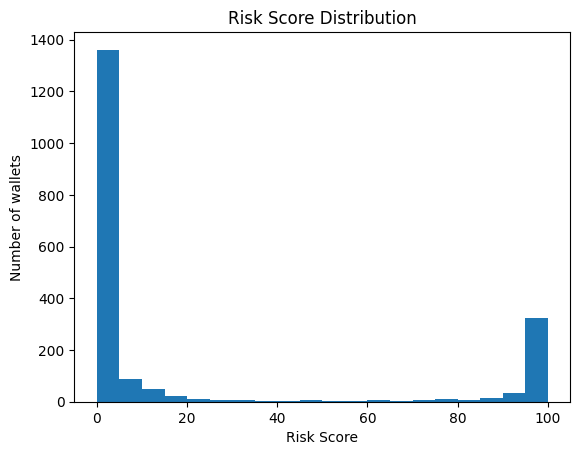

risk_level
HIGH      1.000000
LOW       0.005856
MEDIUM    0.861111
Name: actual_label, dtype: float64


In [30]:
import matplotlib.pyplot as plt

plt.hist(risk_scores, bins=20)
plt.xlabel('Risk Score')
plt.ylabel('Number of wallets')
plt.title('Risk Score Distribution')
plt.show()

# Also check: does risk level roughly line up with actual fraud?
print(results_df.groupby('risk_level')['actual_label'].mean())

Export the model + everything needed to reproduce features

In [31]:
import joblib
import json

# Save the trained model
joblib.dump(model, '/content/drive/MyDrive/AdaptChain/risk_model.pkl')

# Save the exact feature column order the model expects
feature_columns = X.columns.tolist()
with open('/content/drive/MyDrive/AdaptChain/feature_columns.json', 'w') as f:
    json.dump(feature_columns, f)

# Save the top-10 token lists used for encoding, so new data gets bucketed the same way
token_config = {
    'top_sent_tokens': list(top_sent_tokens),
    'top_rec_tokens': list(top_rec_tokens),
    'sent_col': sent_col,
    'rec_col': rec_col
}
with open('/content/drive/MyDrive/AdaptChain/token_config.json', 'w') as f:
    json.dump(token_config, f)

print("Model and config saved!")

Model and config saved!


predict.py code

In [40]:
%%writefile predict.py
"""
predict.py — AdaptChain Risk Scoring Module

Loads the trained Random Forest model and applies the exact same
preprocessing used during training, so raw transaction data can be
turned into a 0-100 risk score, a risk level, and top contributing reasons.
"""

import joblib
import json
import pandas as pd
import numpy as np

MODEL_PATH = 'risk_model.pkl'
FEATURE_COLUMNS_PATH = 'feature_columns.json'
TOKEN_CONFIG_PATH = 'token_config.json'

# Load model and config once, when this module is imported —
# not on every prediction, since loading is slow but predicting is fast.
model = joblib.load(MODEL_PATH)

with open(FEATURE_COLUMNS_PATH, 'r') as f:
    FEATURE_COLUMNS = json.load(f)

with open(TOKEN_CONFIG_PATH, 'r') as f:
    token_config = json.load(f)

SENT_COL = token_config['sent_col']
REC_COL = token_config['rec_col']
TOP_SENT_TOKENS = set(token_config['top_sent_tokens'])
TOP_REC_TOKENS = set(token_config['top_rec_tokens'])

# Pre-compute overall feature importances once (used to pick which
# features are even worth mentioning as "reasons")
FEATURE_IMPORTANCES = dict(zip(FEATURE_COLUMNS, model.feature_importances_))
TOP_GLOBAL_FEATURES = [
    f for f, _ in sorted(FEATURE_IMPORTANCES.items(), key=lambda x: -x[1])
][:15]  # only ever consider the 15 most globally important features as "reasons"


def risk_level(score: int) -> str:
    """Bucket a 0-100 score into AdaptChain's risk tiers."""
    if score <= 30:
        return "LOW"
    elif score <= 70:
        return "MEDIUM"
    else:
        return "HIGH"


def preprocess(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Take a raw transaction DataFrame (same columns as the original
    Kaggle dataset, minus the label) and turn it into the exact
    feature format the model expects.
    """
    df = raw_df.copy()

    for col in ['Unnamed: 0', 'Index', 'Address', 'FLAG']:
        if col in df.columns:
            df = df.drop(columns=[col])

    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype == 'object':
                df[col] = df[col].fillna('None')
            else:
                df[col] = df[col].fillna(0)

    if SENT_COL in df.columns:
        df[SENT_COL] = df[SENT_COL].apply(
            lambda x: x if x in TOP_SENT_TOKENS else 'Other'
        )
    if REC_COL in df.columns:
        df[REC_COL] = df[REC_COL].apply(
            lambda x: x if x in TOP_REC_TOKENS else 'Other'
        )

    df_encoded = pd.get_dummies(df, columns=[SENT_COL, REC_COL], drop_first=True)
    df_encoded = df_encoded.reindex(columns=FEATURE_COLUMNS, fill_value=0)

    return df_encoded


def get_reasons(row: pd.Series, top_n: int = 3) -> list:
    """
    For one transaction's processed feature row, return the top_n
    globally-important features with the highest values — a simple,
    fast approximation of "why this score", without needing SHAP.
    """
    # Look only among features that matter globally, then rank THIS
    # row's values among them (higher value = more likely a driver)
    candidate_values = {f: row[f] for f in TOP_GLOBAL_FEATURES}
    ranked = sorted(candidate_values.items(), key=lambda x: -x[1])
    top_features = [f for f, v in ranked[:top_n] if v > 0]
    return top_features


def predict_risk(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Main entry point. Takes raw transaction data, returns a DataFrame
    with risk_score, risk_level, and top_reasons added.
    """
    X = preprocess(raw_df)

    probabilities = model.predict_proba(X)[:, 1]
    scores = (probabilities * 100).round().astype(int)
    levels = [risk_level(s) for s in scores]
    reasons = [get_reasons(X.iloc[i]) for i in range(len(X))]

    result = raw_df.copy()
    result['risk_score'] = scores
    result['risk_level'] = levels
    result['top_reasons'] = reasons

    return result


if __name__ == '__main__':
    sample = pd.read_csv('transaction_dataset.csv').drop(columns=['FLAG']).head(3)
    output = predict_risk(sample)
    print(output[['risk_score', 'risk_level', 'top_reasons']])

Overwriting predict.py


In [35]:
!cp /content/drive/MyDrive/AdaptChain/risk_model.pkl .
!cp /content/drive/MyDrive/AdaptChain/feature_columns.json .
!cp /content/drive/MyDrive/AdaptChain/token_config.json .

!ls

drive				     predict.py      token_config.json
ethereum-frauddetection-dataset.zip  risk_model.pkl  transaction_dataset.csv
feature_columns.json		     sample_data


In [41]:
!python predict.py

   risk_score risk_level                                        top_reasons
0           1        LOW  [ ERC20 total Ether received, Time Diff betwee...
1           1        LOW  [Time Diff between first and last (Mins), Avg ...
2          33     MEDIUM  [Time Diff between first and last (Mins), Avg ...


In [43]:
!cp predict.py /content/drive/MyDrive/AdaptChain/